In [1]:
%load_ext autoreload
%autoreload 2

from trees.causal_tree import CT
from trees.scanners import *
from trees.data import Data

D = Data()
D.generate(seed=1)

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,outcome,treatment,ITE,id
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,0.016333,0.016357,0.002555,0.008779,0.014647,-0.000694,-0.001358,-0.012730,0.013282,-0.004639,1.402356,0.486100,0.829563,4999.50000
std,1.004344,0.995399,1.002061,0.990194,1.006272,0.997335,1.003758,0.992082,0.988658,1.003042,3.308234,0.499832,1.127446,2886.89568
min,-3.656440,-3.561627,-4.041680,-4.088489,-3.927514,-3.694204,-4.326887,-3.936503,-3.943142,-3.717130,-11.115662,0.000000,-3.402950,0.00000
25%,-0.670257,-0.658037,-0.664461,-0.664934,-0.677336,-0.665069,-0.678350,-0.691577,-0.646222,-0.672351,-0.820162,0.000000,0.054987,2499.75000
50%,0.023696,0.001688,0.010100,0.018078,0.026985,-0.010995,-0.009655,-0.004745,0.019104,-0.009619,1.357399,0.000000,0.819474,4999.50000
75%,0.694073,0.684831,0.683745,0.678851,0.683389,0.652315,0.670513,0.650550,0.687027,0.653546,3.605168,1.000000,1.594184,7499.25000
max,3.702193,3.786966,3.664094,3.997723,4.055538,4.026849,4.168118,3.559969,3.590576,3.500256,15.034705,1.000000,5.699570,9999.00000


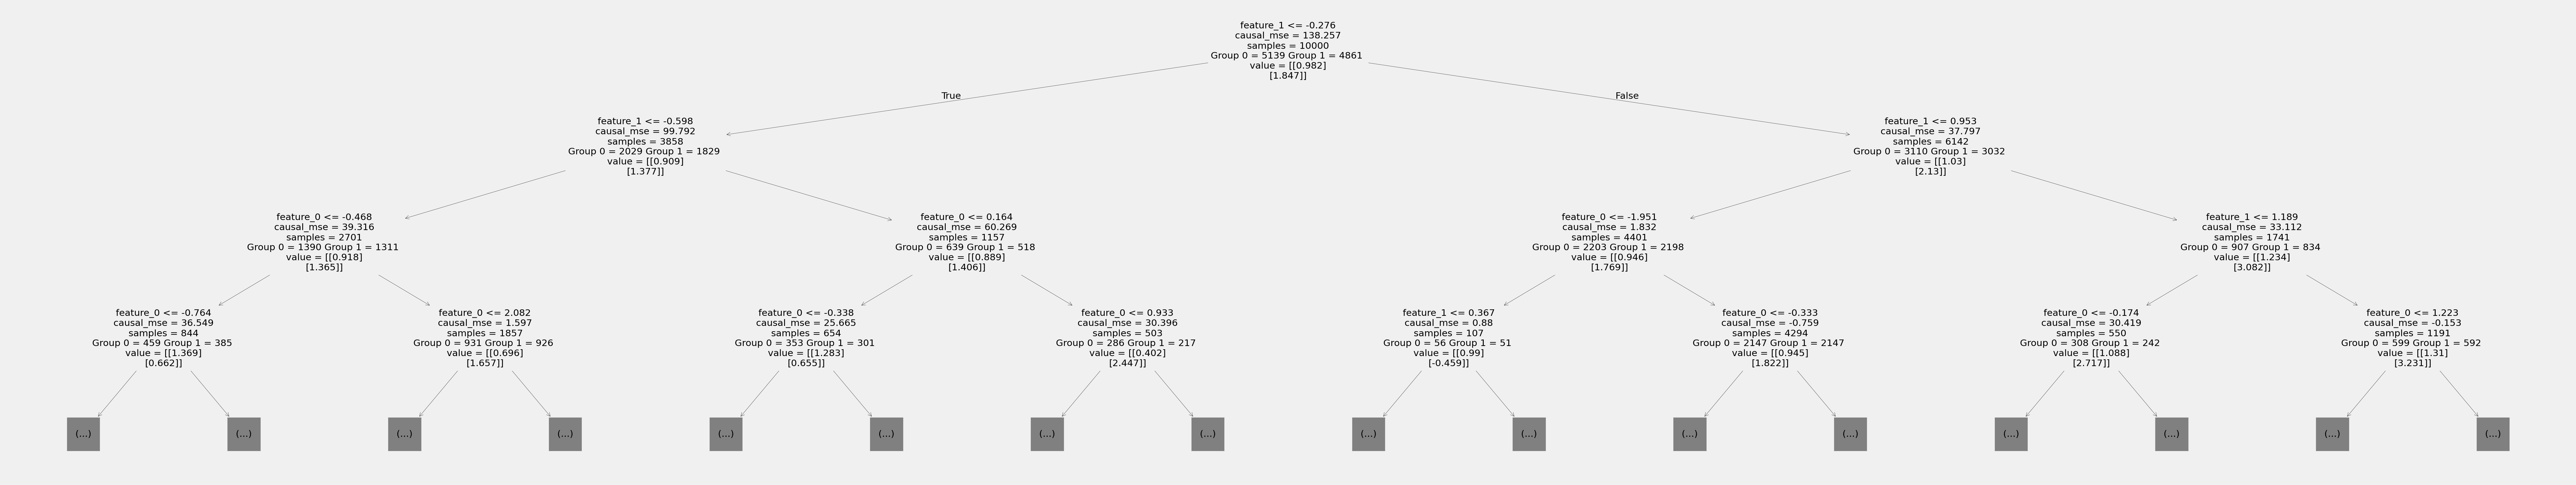

In [2]:
alg = CT()
alg.fit(D=D)
alg.plot_tree(max_depth=3)

In [3]:
alg.subgroups

{1: {'id': 1,
  'condition': 'feature_1 <= -0.276',
  'combined': {'feature_1': (-3.562, -0.276)},
  'features': 1,
  't_est': 0.468,
  'T0': 0.91,
  'T1': 1.38,
  'depth': 1,
  'algorithm': '[Hybrid] CT on D',
  'parents': []},
 2: {'id': 2,
  'condition': 'feature_1 <= -0.276 AND feature_1 <= -0.598',
  'combined': {'feature_1': (-3.562, -0.598)},
  'features': 1,
  't_est': 0.447,
  'T0': 0.92,
  'T1': 1.37,
  'depth': 2,
  'algorithm': '[Hybrid] CT on D',
  'parents': [1]},
 3: {'id': 3,
  'condition': 'feature_1 <= -0.276 AND feature_1 <= -0.598 AND feature_0 <= -0.468',
  'combined': {'feature_1': (-3.562, -0.598), 'feature_0': (-3.656, -0.468)},
  'features': 2,
  't_est': 0.707,
  'T0': 1.37,
  'T1': 0.66,
  'depth': 3,
  'algorithm': '[Hybrid] CT on D',
  'parents': [1, 2]},
 4: {'id': 4,
  'condition': 'feature_1 <= -0.276 AND feature_1 <= -0.598 AND feature_0 <= -0.468 AND feature_0 <= -0.764',
  'combined': {'feature_1': (-3.562, -0.598), 'feature_0': (-3.656, -0.764)},
  '

In [4]:
alg.feature_importances()

,importance,feature
0,0.148527,feature_0
1,0.851473,feature_1


In [5]:
D.generate_random_condition()

User condition: feature_8 <= 2.197 AND feature_6 <= 0.268 Selectivity: 0.598


('feature_8 <= 2.197 AND feature_6 <= 0.268', 0.598)

In [7]:
alg.online()

Total subgroups: 510 Valid subgroups: 295
Pruned due to min rows: 215
Pruned due to not being subsets: 0


In [8]:
scan = Weighted(alg)
top = scan.get_topK()
top

100%|██████████| 510/510 [00:02<00:00, 229.86it/s]


,id,condition,combined,features,t_est,T0,T1,depth,algorithm,parents,...,t_r,scan_method,scan_time,total_options,rows,overlap,score,t_error,t_r_error,invalid_options
0,419,feature_1 > -0.276 AND feature_1 <= 0.953 AND ...,"{'feature_1': (-0.276, 0.953), 'feature_0': (2...",2,4.354,0.74,5.09,5,[Hybrid] CT on D,"[200, 201, 205, 283]",...,3.329,Weighted,2.223,510,50,0.0,1.000000,1.038,0.013,215
1,502,feature_1 > -0.276 AND feature_1 > 0.953 AND f...,"{'feature_1': (1.517, 2.213), 'feature_0': (0....",2,4.031,0.94,4.97,15,[Hybrid] CT on D,"[200, 422, 450, 451, 453, 483, 485, 487, 489, ...",...,2.887,Weighted,2.223,510,34,0.0,0.962908,1.120,0.024,215
2,319,feature_1 > -0.276 AND feature_1 <= 0.953 AND ...,"{'feature_1': (-0.276, 0.009), 'feature_0': (1...",2,3.789,0.07,3.86,9,[Hybrid] CT on D,"[200, 201, 205, 283, 284, 285, 286, 318]",...,2.166,Weighted,2.223,510,34,0.0,0.935117,1.629,0.006,215
3,374,feature_1 > -0.276 AND feature_1 <= 0.953 AND ...,"{'feature_1': (0.355, 0.542), 'feature_0': (0....",2,3.665,0.22,3.88,15,[Hybrid] CT on D,"[200, 201, 205, 283, 284, 330, 331, 332, 336, ...",...,2.025,Weighted,2.223,510,34,0.0,0.920877,1.663,0.023,215
4,504,feature_1 > -0.276 AND feature_1 > 0.953 AND f...,"{'feature_1': (1.189, 3.787), 'feature_0': (1....",2,3.348,2.06,5.41,4,[Hybrid] CT on D,"[200, 422, 450]",...,3.584,Weighted,2.223,510,77,0.0,0.884474,0.287,0.051,215


# CT on P

In [9]:
%load_ext autoreload
%autoreload 2

from trees.causal_tree import CTP
from trees.scanners import *
from trees.data import Data

D = Data()
D.generate(seed=1)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,outcome,treatment,ITE,id
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,0.016333,0.016357,0.002555,0.008779,0.014647,-0.000694,-0.001358,-0.012730,0.013282,-0.004639,1.402356,0.486100,0.829563,4999.50000
std,1.004344,0.995399,1.002061,0.990194,1.006272,0.997335,1.003758,0.992082,0.988658,1.003042,3.308234,0.499832,1.127446,2886.89568
min,-3.656440,-3.561627,-4.041680,-4.088489,-3.927514,-3.694204,-4.326887,-3.936503,-3.943142,-3.717130,-11.115662,0.000000,-3.402950,0.00000
25%,-0.670257,-0.658037,-0.664461,-0.664934,-0.677336,-0.665069,-0.678350,-0.691577,-0.646222,-0.672351,-0.820162,0.000000,0.054987,2499.75000
50%,0.023696,0.001688,0.010100,0.018078,0.026985,-0.010995,-0.009655,-0.004745,0.019104,-0.009619,1.357399,0.000000,0.819474,4999.50000
75%,0.694073,0.684831,0.683745,0.678851,0.683389,0.652315,0.670513,0.650550,0.687027,0.653546,3.605168,1.000000,1.594184,7499.25000
max,3.702193,3.786966,3.664094,3.997723,4.055538,4.026849,4.168118,3.559969,3.590576,3.500256,15.034705,1.000000,5.699570,9999.00000


In [10]:
alg = CTP()
alg.fit(D=D)
D.generate_random_condition()

User condition: feature_8 <= 2.197 AND feature_6 <= 0.268 Selectivity: 0.598


('feature_8 <= 2.197 AND feature_6 <= 0.268', 0.598)

Subgroups: 298


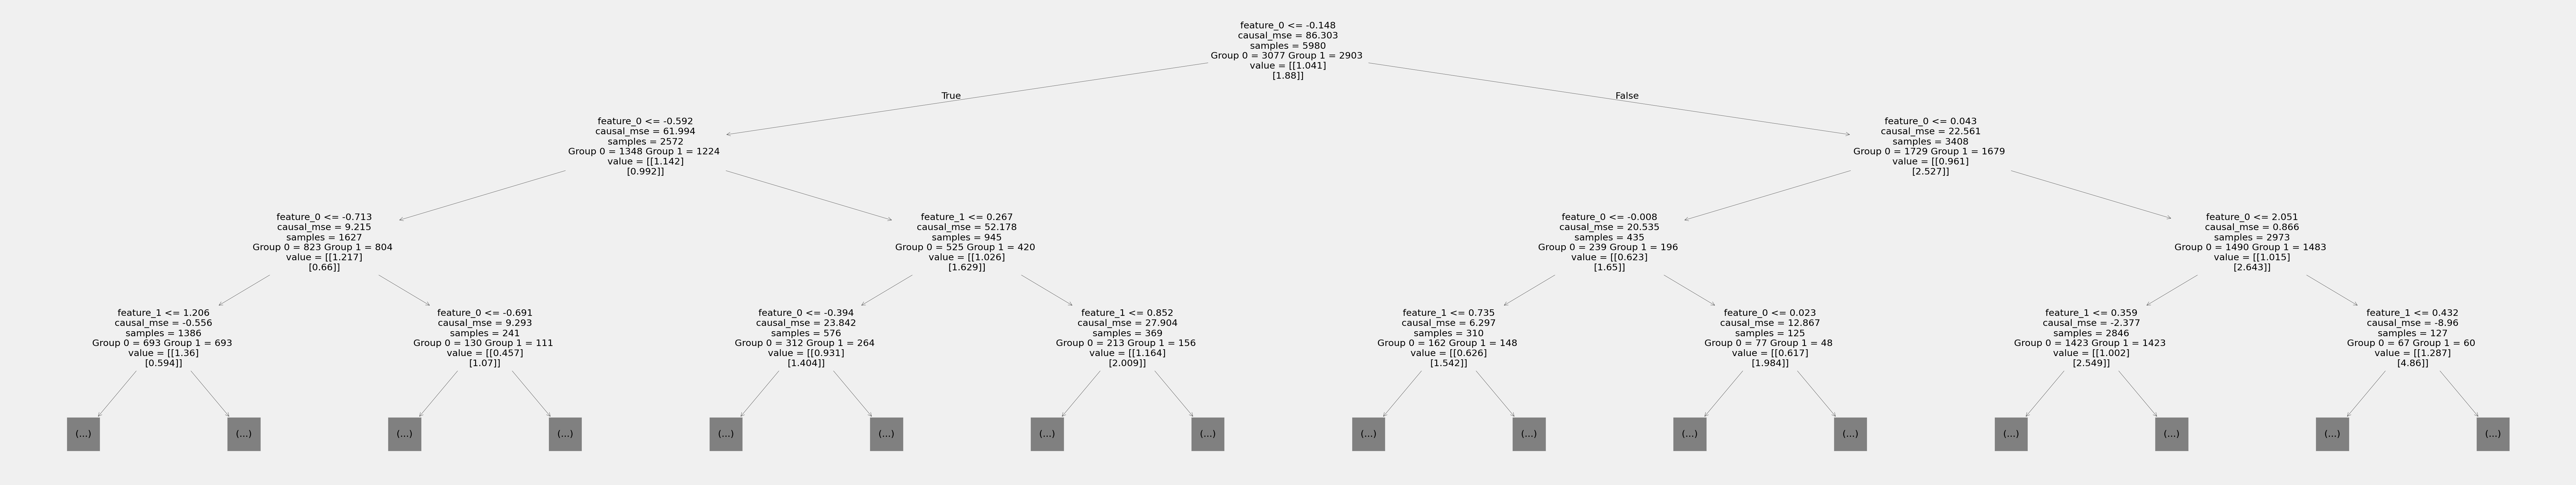

In [13]:
alg.online()
alg.plot_tree(max_depth=3)

In [14]:
scan = Weighted(alg)
top = scan.get_topK()
top


100%|██████████| 298/298 [00:01<00:00, 263.10it/s]


,id,condition,combined,features,t_est,T0,T1,depth,algorithm,parents,...,t_r,scan_method,scan_time,total_options,rows,overlap,score,t_error,t_r_error,invalid_options
0,289,feature_0 > -0.148 AND feature_0 > 0.043 AND f...,"{'feature_0': (0.043, 0.526), 'feature_1': (1....",2,5.792,-1.03,4.77,7,[Online] CT on P,"[130, 148, 149, 247, 287, 288]",...,2.135,Weighted,1.136,298,30,0.0,1.000000,3.662,0.005,0
1,298,feature_0 > -0.148 AND feature_0 > 0.043 AND f...,"{'feature_0': (2.051, 3.702), 'feature_1': (0....",2,5.093,0.95,6.04,4,[Online] CT on P,"[130, 148, 294]",...,3.812,Weighted,1.136,298,39,0.0,0.939658,1.192,0.089,0
2,21,feature_0 <= -0.148 AND feature_0 <= -0.592 AN...,"{'feature_0': (-2.071, -1.677), 'feature_1': (...",2,4.639,3.95,-0.69,14,[Online] CT on P,"[1, 2, 3, 4, 6, 7, 8, 9, 13, 15, 16, 17, 19]",...,1.006,Weighted,1.136,298,31,0.0,0.900466,3.617,0.016,0
3,244,feature_0 > -0.148 AND feature_0 > 0.043 AND f...,"{'feature_0': (1.537, 1.641), 'feature_1': (-0...",2,4.462,-0.61,3.85,9,[Online] CT on P,"[130, 148, 149, 150, 224, 225, 239, 243]",...,2.269,Weighted,1.136,298,34,0.0,0.885186,2.197,0.004,0
4,242,feature_0 > -0.148 AND feature_0 > 0.043 AND f...,"{'feature_0': (1.537, 1.819), 'feature_1': (-1...",2,4.416,-0.47,3.95,9,[Online] CT on P,"[130, 148, 149, 150, 224, 225, 239, 240]",...,2.022,Weighted,1.136,298,34,0.0,0.881215,2.392,0.002,0
